## 学習と精度を確認する
- RF、XGBoost、LGBMで学習と精度を確認
- テキストのみで予測するパターンと、テーブルデータとして予測するパターンを追加
- 直近N年の評価をValidationデータ、それ以外を学習データとして利用
- LGBMは交差検証とOOFによる閾値最適化を実施

In [17]:
from importlib import reload

from classification import ml_token_classification_rf
from classification import ml_token_classification_xgb
from classification import ml_token_classification_lgb

from classification import ml_numerical_classification_rf
from classification import ml_numerical_classification_xgb
from classification import ml_numerical_classification_lgb

from classification import cm

from sklearn.model_selection import train_test_split

import numpy as np


In [19]:
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

# ====== パラメータ（必要に応じて変更） ======
RANDOM_SEED = 42
N_SPLITS = 10
# 列名
TEXT_COL = "description"          # テキスト列
LABEL_BINARY_COL = "eval_binary"  # 目的変数（0/1）
YEAR_COL = "project_start_year"   # 年度列（数値化可能であること）
THRESHOLD = 100 # 閾値
THRESH_OBJECTIVE = "balanced_accuracy"  # 閾値最適化の指標

# テストに使う直近年数
TEST_LAST_N = 10
# cost_success_flg, duration_success_flg, total_eval
SOURCE_ORDINAL_COL = "total_eval"

In [20]:
import pandas as pd
df_ori = pd.read_csv("../df_check_ml.csv")  # ←必要ならCSV読み込み

df_ori.columns

Index(['Unnamed: 0_x', 'file', 'country', 'eval_year', 'evaluator_group',
       'evaluator', 'project_cost_plan', 'project_cost_act', 'プロジェクト期間開始_計画時',
       'プロジェクト期間終了_計画時', 'プロジェクト期間開始_実績', 'プロジェクト期間終了_実績',
       'project_duration_plan', 'project_duration_act', '妥当性評価', '整合性評価',
       '有効性評価', 'インパクト評価', '効率性評価', '効率性_コスト', '効率性_期間', '持続性評価', '適応・貢献評価',
       '付加価値・創造価値評価', '総合評価', '備考', 'type', '分野', '案件名', '連番', 'region',
       'region_detail', 'alpha2', 'alpha3', 'project_start_year',
       'project_end_year', 'join_flg_x', 'Year', 'external_eval_flg',
       'その他_flg_fix', 'インフラ_flg_fix', 'エネルギー一般_flg_fix', '人材・教育_flg_fix',
       '保健・社会福祉_flg_fix', '公益事業一般_flg_fix', '商業経営_flg_fix', '工業_flg_fix',
       '放送_flg_fix', '林業・森林保全_flg_fix', '水産_flg_fix', '水資源開発_flg_fix',
       '海運_flg_fix', '測量・地図_flg_fix', '災害・食料援助_flg_fix', '災害対策_flg_fix',
       '環境_flg_fix', '畜産_flg_fix', '社会基盤一般_flg_fix', '航空・空港_flg_fix',
       '行政一般_flg_fix', '観光一般_flg_fix', '貿易_flg_fix', '農業一般_flg_fix

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


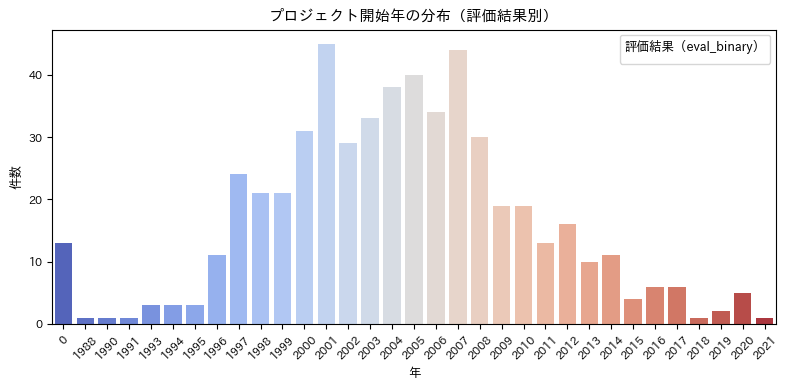

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

df_yusho = df_ori[df_ori['type']=="有償"]

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_yusho,
    x=YEAR_COL,
    palette="coolwarm"
)
plt.title("プロジェクト開始年の分布（評価結果別）", fontsize=11)  # タイトル小さく
plt.xlabel("年", fontsize=9)                     # 軸ラベル小さく
plt.ylabel("件数", fontsize=9)
plt.xticks(rotation=45, fontsize=8)                              # x軸目盛りの文字サイズ
plt.yticks(fontsize=8)                                           # y軸目盛りの文字サイズ
plt.legend(title="評価結果（eval_binary）", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()

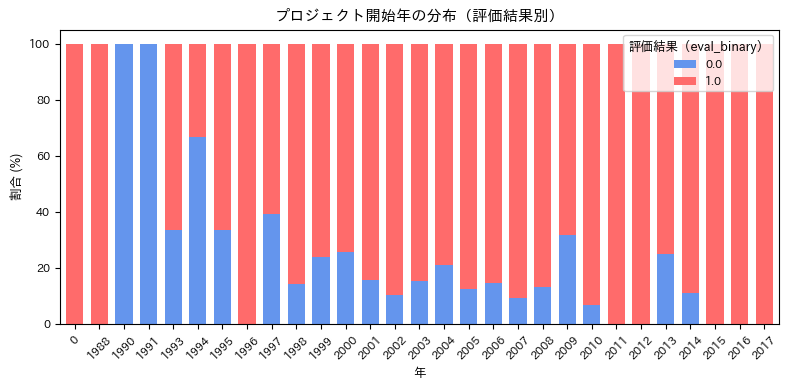

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

df_yusho = df_ori[df_ori['type']=="有償"]

# 年ごとの評価結果の集計
year_eval_counts = df_yusho.groupby([YEAR_COL, 'eval_binary']).size().unstack(fill_value=0)

# 割合に変換（各年の合計で割る）
year_eval_proportions = year_eval_counts.div(year_eval_counts.sum(axis=1), axis=0) * 100

# 積み上げ棒グラフを作成
plt.figure(figsize=(8, 4))
year_eval_proportions.plot(
    kind='bar',
    stacked=True,
    color=['#6495ED', '#FF6B6B'],  # coolwarmに近い色
    width=0.7,
    ax=plt.gca()
)

plt.title("プロジェクト開始年の分布（評価結果別）", fontsize=11)
plt.xlabel("年", fontsize=9)
plt.ylabel("割合 (%)", fontsize=9)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(title="評価結果（eval_binary）", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()

In [23]:
# 利用するテキストの特徴量を生成
df_ori['sentence'] = df_ori['background']+df_ori['description']

In [24]:
## 評価がないレコードを除外
print(df_ori['eval_binary'].isnull().sum())
df_ori = df_ori.dropna(subset=['eval_binary'])

50


In [25]:
df_ori = df_ori.rename(columns={
  LABEL_BINARY_COL: "label",
})

In [26]:
## textがないレコードを除外
print(df_ori['sentence'].isnull().sum())
df = df_ori.dropna(subset=['sentence'])

8


In [27]:
## train_test分割
train_df = df[df[YEAR_COL] <= (df[YEAR_COL].max() - TEST_LAST_N)]
valid_df = df[df[YEAR_COL] > (df[YEAR_COL].max() - TEST_LAST_N)]

valid_df = valid_df[valid_df['type']=="有償"]

In [28]:
valid_df[YEAR_COL].max()

2017

In [29]:
train_df[YEAR_COL].max()

2008

In [30]:
print(len(valid_df),len(valid_df)/len(df))
print(len(train_df),len(train_df)/len(df))

81 0.03734439834024896
1011 0.4661134163208852


In [31]:
print(len(valid_df[valid_df['type']=="有償"]))
print(len(valid_df[valid_df['type']=="無償"]))
print(len(valid_df[valid_df['type']=="技協"]))

81
0
0


In [32]:
train_df

,Unnamed: 0_x,file,country,eval_year,evaluator_group,evaluator,project_cost_plan,project_cost_act,プロジェクト期間開始_計画時,プロジェクト期間終了_計画時,...,conclusion,validity,inpact,effectiveness,sustainability,background,description,description_detail,label,sentence
0,0,https://www2.jica.go.jp/ja/evaluation/pdf/2010...,ケニア,2010,OPMAC株式会社,小林信行,1.110900e+09,1.019900e+09,2002-01-01,2005-11-20,...,本事業で実施したアティ橋、イクサ橋の架け替えは既存道路網の維持管理を重視するケニアの開発政策...,事前評価時における国家開発計画は、過去10年以上にわたり進行した道路インフラの劣化は不十分な...,本事業は落橋のリスクに対応し、円滑な交通を確保することが主な目的であるため、交通量と通行可能...,本事業の主なアウトプットである橋梁に関しては計画通りに建設されており、事業効果に影響を与える...,事前評価時点から事後評価時点にかけて、ケニアの道路当局は大幅に再編され、道路省が長期計画を策...,アフリカ東部に位置するケニアは1999年の段階で約15万キロの道路網が整備されており、国内物...,ケニア東部州において国道B7号線の二橋梁(アティ橋、イクサ橋)を架け替えることにより、安全で...,ケニアは1999年時点で約15万キロの道路網を持ち、国内物流の9割が道路輸送に依存。モンバサ...,1.0,アフリカ東部に位置するケニアは1999年の段階で約15万キロの道路網が整備されており、国内物...
1,1,https://www2.jica.go.jp/ja/evaluation/pdf/2010...,ベトナム,2010,グローバルリンクマネージメント株式会社,三浦順子,2.235000e+09,2.206000e+09,2002-07-01,2006-01-01,...,本事業は計画時、事業評価時点共に、ベトナム国の開発政策、開発ニーズとの整合性が高く、計画時の...,計画時におけるベトナム国の地方給水・衛生セクターの基本政策である「国家地方給水・衛生戦略 2...,本事業の実施は、計画時想定された、1)水因性疾病罹患率の減少、2)水汲み労働の軽減、に貢献し...,"日越双方ほぼ計画通りのアウトプットであり、予定通りの給水能力(7,490 ㎡/日)の施設が完...",ニンビン省とタンホア省ではCPC、タイグエン省ではP-CERWASSが給水施設の運営・維持管...,本事業対象地域は農村部に属し、2001年時点で公共給水施設が皆無であり、住民は浅井戸地下水や...,タイグエン省4コミューン、ニンビン省3コミューン、タンホア省5コミューン、計 12 コミュー...,本事業対象地域は、2001年時点で公共給水施設が皆無の農村部であり、住民は浅井戸や地表水を利...,1.0,本事業対象地域は農村部に属し、2001年時点で公共給水施設が皆無であり、住民は浅井戸地下水や...
2,2,https://www2.jica.go.jp/ja/evaluation/pdf/2010...,モンゴル,2010,財団法人国際開発高等教育機構,浜岡真紀,NaN,NaN,2002-06-17,2003-06-15,...,本事業は、対象10校において初等教育施設及び機材を整備することにより、教室の過密状況を緩和し...,本事業の目的は、事前評価時(2002年)、事後評価時(2011年)においてモンゴル国の国家開...,各学校への質問票回答や現地視察、受益者調査の結果から、以下のインパクトが確認された。学校が近...,日本側のアウトプットについては、軽微な設計変更はあったが、計画通りに対象10校において初等教...,本事業により整備された施設・機材の維持管理体制に問題はない。各学校に機材・設備担当者が配置さ...,モンゴルは、1990年代以降、民主化と市場経済化推進に対応できる人的資源開発を最重要課題とし...,本事業は、対象10校において初等教育施設及び機材を整備することにより、教室の過密状況を緩和し...,モンゴルでは1990年代以降の市場経済化に伴う財政悪化により教育予算が削減され、教職員・教育...,1.0,モンゴルは、1990年代以降、民主化と市場経済化推進に対応できる人的資源開発を最重要課題とし...
3,3,https://www2.jica.go.jp/ja/evaluation/pdf/2010...,中華人民共和国,2010,アイ・シー・ネット株式会社,岸野優子,1.785000e+09,1.718000e+09,2003-03-01,2008-01-29,...,本事業は、中国政府の森林被覆率の改善を目標とした森林造成計画の中で、自然環境、立地条件ともに...,本協力対象事業は、中国政府の森林被覆率の改善を目標とした森林造成計画の中で、自然環境・立地条...,事業対象4県4地区の森林被覆率は、事業実施前の8.3%から評価時の66.4%へ大幅に向上し、...,本事業のアウトプットはほぼ計画通り実施された。植林面積は計画通りであり、ソフトコンポーネント...,実施機関である山西省林業庁は、事業完了後も組織体制に大きな変更はなく、運営維持管理体制に問題...,中国では、木材生産のための森林伐採や、食糧確保のための過剰な開墾が進み、森林は国土面積の 1...,山西省昕水河流域(吉県、大寧県、蒲県、隰県)において植林技術普及のモデルとなる森林を造成する...,本事業は、中国で進行する森林減少と、特に黄河中流域の黄土高原における深刻な土砂流出問題に対応...,1.0,中国では、木材生産のための森林伐採や、食糧確保のための過剰な開墾が進み、森林は国土面積の 1...
4,4,https://www2.jica.go.jp/ja/evaluation/pdf/2010...,ベトナム,2010,グローバルリンクマネージメント株式会社,三浦順子,2.277000e+09,2.271000e+09,2003-05-01,2006-03-01,...,本事業の実施は、ベトナムの開発政策及び日本の援助政策と合致している。開発ニーズに関しては、計...,本事業の実施はベトナムの開発政策及び日本の援助政策と合致している。開発ニーズに関しては、計画...,計画時、本事業の実施は、1) 麻疹ワクチン2回接種対象者数、接種者数及び接種率の維持、2)乳...,本事業は事業費及び事業期間ともにほぼ計画通りであり効率性は高い。,1)過去半年の間に異常・逸脱時の対応や製造原価削減のための変更管理が適切に行われなかった事例...,ベトナム社会主義共和国(以下、ベトナム)政府は、乳児死亡率、5 歳未満児死亡率の低減及び感染...,ベトナム国ハノイ市において、ベトナム国唯一の麻疹ワクチン製造施設および品質管理施設の建設、製...,ベトナム政府は感染症対策として予防接種拡大計画を実施し、ワクチン自給を目指す中、麻疹ワクチン...,1.0,ベトナム社会主義共和国(以下、ベトナム)政府は、乳児死亡率、5 歳未満児死亡率の低減及び感染...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,2196,https://www2.jica.go.jp/ja/evaluation/pdf/2023...,モンゴル,2023,オクタヴィアジャパン株式会社,高橋久恵,6.849328e+10,7.089600e+10,2008-05-01,2016-05-10,...,本事業は、首都ウランバートル郊外に新空港を建設することにより、首都空港の安全性・信頼性の改善...,本事業は審査時、事後評価時ともにモンゴルの開発政策、開発ニーズと整合する。JICA 内外の事...,本事業の審査時、新空港の建設が外国投資の増大や航空輸送力の強化を通じて、社会・経済の活性化に...,本事業では、コントラクターの契約金額の増大やモンゴル側の財政事情の悪化による資金不足から2期...,2025年施行のCivil Aviation Law（2023年）や2022年の国会決議14...,モンゴルでは、1990年以降の国有資産の民営化、価格・生産の自由化、金融システムの導入等の市...,首都ウランバートル郊外に新空港を建設することにより、首都空港の安全性・信頼性の改善及び利便性...,モンゴルの旧国際空港は地理的制約から拡張が困難で、増加する海外渡航者需要に対応できず、遅延や...,1.0,モンゴルでは、1990年以降の国有資産の民営化、価格・生産の自由化、金融システムの導入等の市...
2197,2197,https://www2.jica.go.jp/ja/evaluation/pdf/2023...,ネパール,2023,株式会社国際開発センター,末吉由起子,6.463000e+09,5.585000e+09,2001-03-01,2007-03-03,...,本事業は、カト

## テキスト外特徴量の追加

## 特徴量指定

In [33]:
df.columns

Index(['Unnamed: 0_x', 'file', 'country', 'eval_year', 'evaluator_group',
       'evaluator', 'project_cost_plan', 'project_cost_act', 'プロジェクト期間開始_計画時',
       'プロジェクト期間終了_計画時', 'プロジェクト期間開始_実績', 'プロジェクト期間終了_実績',
       'project_duration_plan', 'project_duration_act', '妥当性評価', '整合性評価',
       '有効性評価', 'インパクト評価', '効率性評価', '効率性_コスト', '効率性_期間', '持続性評価', '適応・貢献評価',
       '付加価値・創造価値評価', '総合評価', '備考', 'type', '分野', '案件名', '連番', 'region',
       'region_detail', 'alpha2', 'alpha3', 'project_start_year',
       'project_end_year', 'join_flg_x', 'Year', 'external_eval_flg',
       'その他_flg_fix', 'インフラ_flg_fix', 'エネルギー一般_flg_fix', '人材・教育_flg_fix',
       '保健・社会福祉_flg_fix', '公益事業一般_flg_fix', '商業経営_flg_fix', '工業_flg_fix',
       '放送_flg_fix', '林業・森林保全_flg_fix', '水産_flg_fix', '水資源開発_flg_fix',
       '海運_flg_fix', '測量・地図_flg_fix', '災害・食料援助_flg_fix', '災害対策_flg_fix',
       '環境_flg_fix', '畜産_flg_fix', '社会基盤一般_flg_fix', '航空・空港_flg_fix',
       '行政一般_flg_fix', '観光一般_flg_fix', '貿易_flg_fix', '農業一般_flg_fix

In [34]:
ohe_col = [
    #'project_start_year',
    'country',
    'region_detail',
    'type',
]
df = pd.get_dummies(df_ori, columns=ohe_col)


# 例: 既存ノートのfeaturesを再掲。必要に応じて変更/追加してください。
features = [
    'project_cost_plan', 
    'project_duration_plan', 
    'control_of_corruption', 
    'government_effectiveness', 
    'political_stability', 
    'regulatory_quality', 
    'rule_of_law', 
    'voice_and_accountability', 
    'freedom_house_score', 
    'gdp_growth', 
    'population', 
    'sentence', 
]

# one-hot列
country_columns = [c for c in df.columns if c.startswith('country_')]
type_columns = [c for c in df.columns if c.startswith('type_')]
region_columns = [c for c in df.columns if c.startswith('region_detail_')]
project_start_year_columns = [c for c in df.columns if c.startswith('project_start_year')]
sector_columns = [c for c in df.columns if 'flg_fix' in c]
eva_columns = [c for c in df.columns if c.startswith('evaluator_group_')]

features = features + country_columns + type_columns + region_columns + sector_columns + eva_columns


## RandomForest
- 数値系特徴量の追加

In [46]:
## random forest用にNaN特徴量の行を除外
df_random = df.dropna(subset=features)
rf_feat = features.copy()

## train_test分割
train_rf_df = df_random[df_random[YEAR_COL] <= (df_random[YEAR_COL].max() - TEST_LAST_N)][rf_feat + ['label']] 
valid_rf_df = df_random[df_random[YEAR_COL] > (df_random[YEAR_COL].max() - TEST_LAST_N)][rf_feat + ['label']] 
valid_rf_df = valid_rf_df[valid_rf_df['type_有償']]

Accuracy: 0.875
Precision: 0.4375
Recall: 0.5
Macro F1: 0.4666666666666667
Balanced Accuracy: 0.5
SHAP values array shape: (2, 80, 1652)


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


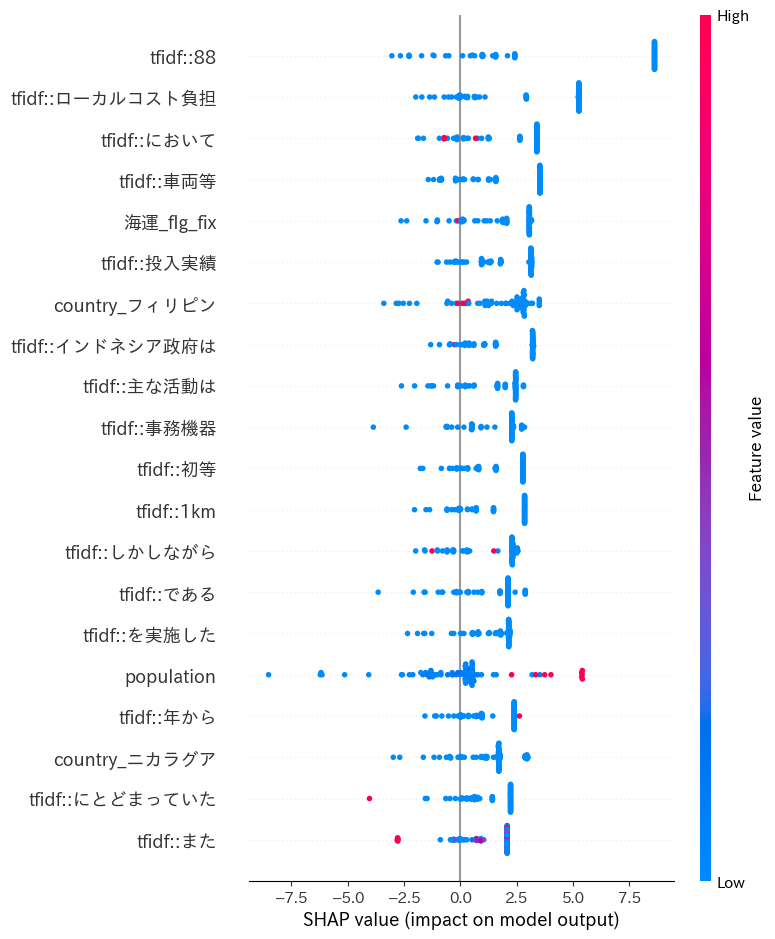

In [47]:
reload(ml_numerical_classification_rf)
ml_numerical_classification_rf.train_and_evaluate_model(train_df=train_rf_df, valid_df=valid_rf_df)



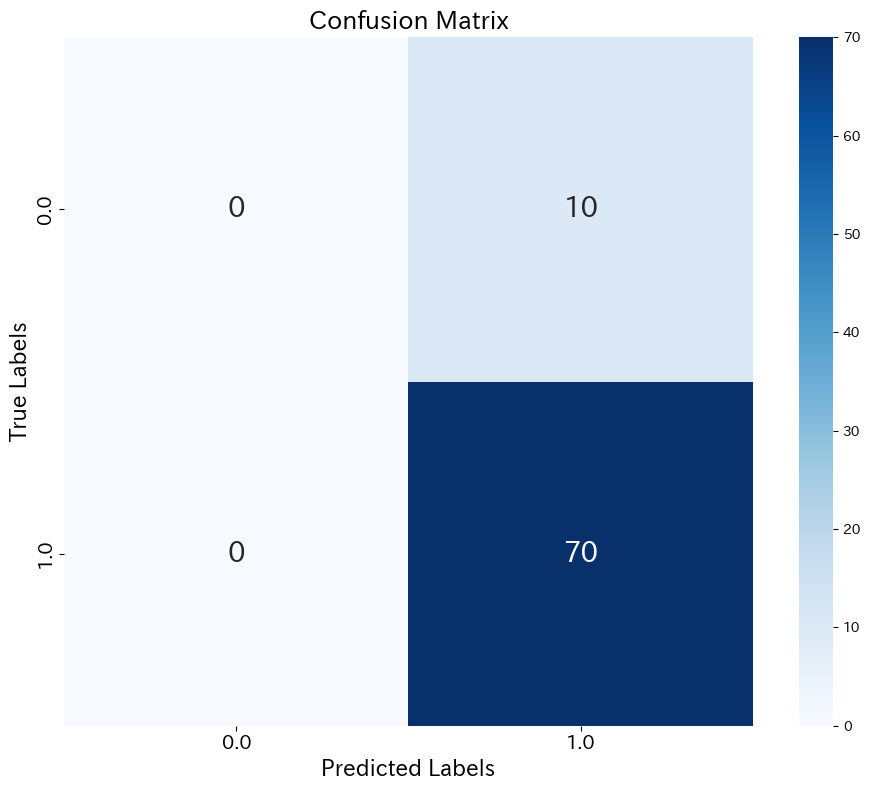

method, class, accuracy, precision, recall
proposed, all, 0.875, 0.4375, 0.5
proposed, 0.0, non, 0.0, 0.0
proposed, 1.0, non, 0.875, 1.0
baseline, all, 0.78125, 0.5, 0.5
baseline, 0.0, non, 0.125, 0.125
baseline, 1.0, non, 0.875, 0.875


Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [48]:
reload(cm)
cm.vis('results/classification/confusion_matrix_num_rf.csv','results/classification/result_num_rf.csv')

## XGBoost
- 数値系特徴量の追加

In [49]:
## train_test分割
train_df = df[df[YEAR_COL] <= (df[YEAR_COL].max() - TEST_LAST_N)][rf_feat + ['label']] 
valid_df = df[df[YEAR_COL] > (df[YEAR_COL].max() - TEST_LAST_N)][rf_feat + ['label']] 
valid_df = valid_df[valid_df['type_有償']]

In [50]:
reload(ml_numerical_classification_xgb)
ml_numerical_classification_xgb.train_and_evaluate_model(train_df=train_df, valid_df=valid_df)

cm.vis('results/classification/confusion_matrix_num_xgb.csv','results/classification/result_num_xgb.csv')


[CV metrics @0.5]
   fold       AUC  MacroF1@0.5  BalAcc@0.5  best_iteration
0     1  0.727059     0.622102    0.618301             524
1     2  0.689804     0.625993    0.639085             153
2     3  0.743034     0.668301    0.717944               9
3     4  0.715428     0.634166    0.639835             130
4     5  0.674149     0.634166    0.639835             140
Mean ± Std
           AUC  MacroF1@0.5  BalAcc@0.5
mean  0.709895     0.636946    0.651000
std   0.027861     0.018295    0.038542
OOF AUC: 0.6889
Best threshold by balanced_accuracy: t=0.512, score=0.6580
Accuracy: 0.8271604938271605
Precision: 0.5702054794520548
Recall: 0.5577464788732395
Macro F1: 0.5625
Balanced Accuracy: 0.5577464788732395


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: <xgboost.core.Booster object at 0x16cd92df0>

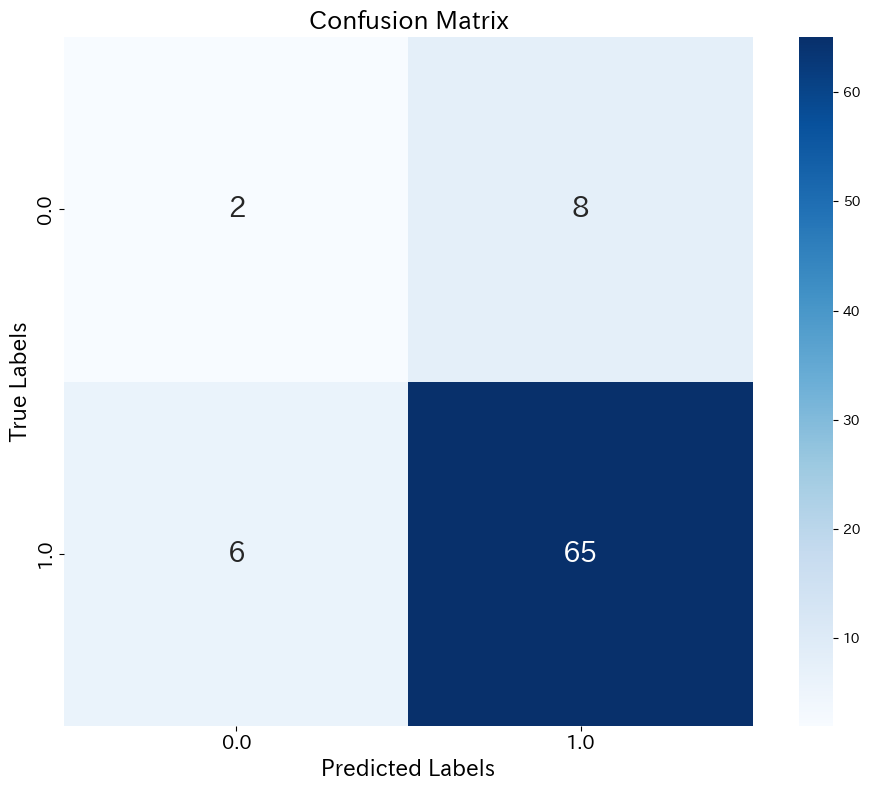

method, class, accuracy, precision, recall
proposed, all, 0.8271604938271605, 0.5702054794520548, 0.5577464788732395
proposed, 0.0, non, 0.25, 0.2
proposed, 1.0, non, 0.8904109589041096, 0.9154929577464789
baseline, all, 0.783569577808261, 0.5, 0.5
baseline, 0.0, non, 0.12345679012345678, 0.12345679012345678
baseline, 1.0, non, 0.8765432098765432, 0.8765432098765432


In [51]:
cm.vis('results/classification/confusion_matrix_num_xgb.csv','results/classification/result_num_xgb.csv')


## lgbm
- 数値系特徴量の追加

In [52]:
## train_test分割
train_df = df[df[YEAR_COL] <= (df[YEAR_COL].max() - TEST_LAST_N)][features + ['label']] 
valid_df = df[df[YEAR_COL] > (df[YEAR_COL].max() - TEST_LAST_N)][features + ['label']] 
valid_df = valid_df[valid_df['type_有償']]

[LightGBM] [Info] Number of positive: 685, number of negative: 228
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4218
[LightGBM] [Info] Number of data points in the train set: 913, number of used features: 144
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.750274 -> initscore=1.100073
[LightGBM] [Info] Start training from score 1.100073
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


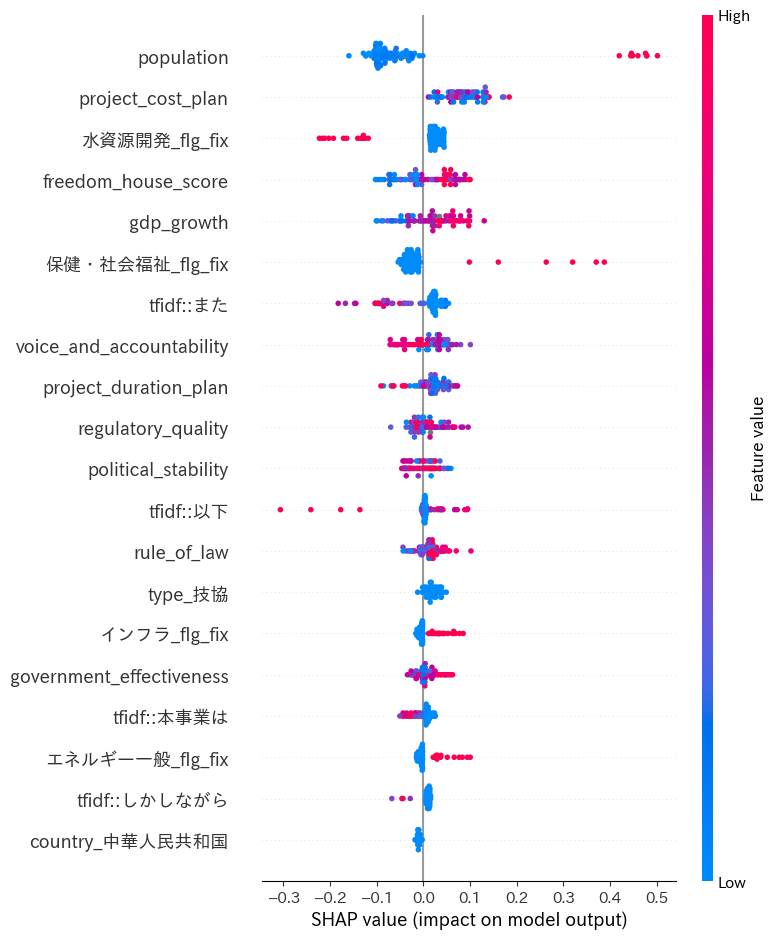

In [53]:
reload(ml_numerical_classification_lgb)
ml_numerical_classification_lgb.train_and_evaluate_model(train_df=train_df, valid_df=valid_df, n_splits=N_SPLITS, threshold_objective="macro_f1")



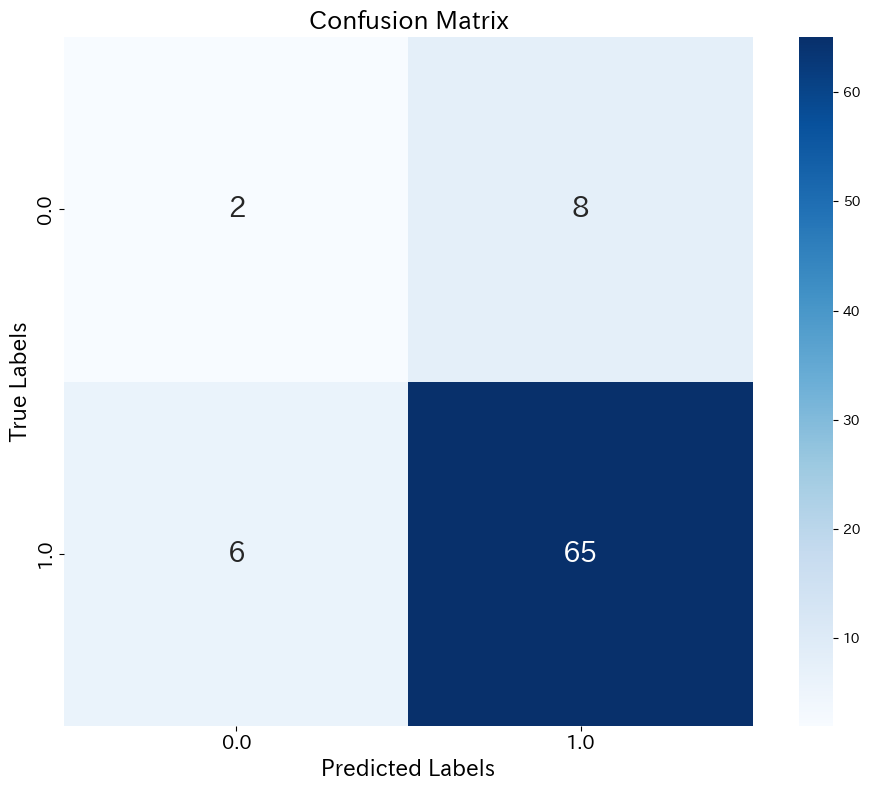

method, class, accuracy, precision, recall
proposed, all, 0.8271604938271605, 0.5702054794520548, 0.5577464788732395
proposed, 0.0, non, 0.25, 0.2
proposed, 1.0, non, 0.8904109589041096, 0.9154929577464789
baseline, all, 0.783569577808261, 0.5, 0.5
baseline, 0.0, non, 0.12345679012345678, 0.12345679012345678
baseline, 1.0, non, 0.8765432098765432, 0.8765432098765432


In [54]:
cm.vis('results/classification/confusion_matrix_num_lgb.csv','results/classification/result_num_lgb.csv')
